In [1]:
import pyuff
import numpy as np

def load_uff_as_wav_format(uff_file_path):
    """
    Загружает UFF файл и преобразует в формат, понятный для основного кода
    Возвращает: fs (частота дискретизации), data (2 канала)
    """
    # Открываем UFF файл
    uff_file = pyuff.UFF(uff_file_path)
    
    # Получаем типы наборов
    set_types = uff_file.get_set_types()
    print(f"Типы наборов: {set_types}")
    
    # Читаем все наборы
    all_datasets = uff_file.read_sets()
    
    # Извлекаем данные
    frequencies = None
    ref_spectrum = None  # эталон
    cal_spectrum = None  # ПГД
    
    for i, dataset in enumerate(all_datasets):
        if isinstance(dataset, dict):
            # Частоты
            if 'x' in dataset:
                frequencies = dataset['x']
            
            # Данные
            if 'y' in dataset:
                data = dataset['y']
            elif 'data' in dataset:
                data = dataset['data']
            else:
                # Ищем первый массив numpy
                for key, value in dataset.items():
                    if isinstance(value, np.ndarray) and key != 'x':
                        data = value
                        break
            
            # Берем модуль если комплексные
            if np.iscomplexobj(data):
                data = np.abs(data)
            
            # Распределяем
            if i == 0:
                ref_spectrum = data
            elif i == 1:
                cal_spectrum = data
    
    if frequencies is None:
        raise ValueError("Не найдены частоты")
    
    # Приводим к 1D если нужно
    if ref_spectrum.ndim > 1:
        ref_spectrum = ref_spectrum[:, 0]
    if cal_spectrum.ndim > 1:
        cal_spectrum = cal_spectrum[:, 0]
    
    # Для совместимости с кодом, который ожидает временные ряды,
    # мы создадим "псевдо-временные" ряды, используя обратное преобразование
    # ИЛИ просто вернем спектры, а fs сделаем равной 2*max_freq
    
    max_freq = frequencies[-1]
    fs = 2 * max_freq  # Частота Найквиста
    
    # Создаем простой массив данных с 2 каналами
    # Для обратной совместимости с вашим кодом
    n_points = len(frequencies)
    
    # Создаем структуру данных как в WAV файле
    data = np.zeros((n_points, 2))
    data[:, 0] = ref_spectrum
    data[:, 1] = cal_spectrum
    
    print(f"\nЗагружено:")
    print(f"  Частот: {n_points}")
    print(f"  Диапазон: {frequencies[0]:.2f} - {frequencies[-1]:.2f} Гц")
    print(f"  Эквивалентная fs: {fs:.1f} Гц")
    
    return fs, data, frequencies

# # ИСПОЛЬЗОВАНИЕ:
# # Загружаем данные
# fs, data, freqs = load_uff_as_wav_format('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-2.uff')

# # Теперь data готова для передачи в ваш код:
# # micr = data[:, 0] - np.mean(data[:, 0])
# # pgd = data[:, 1] - np.mean(data[:, 1])

# # Проверка
# print(f"\nФорма данных: {data.shape}")
# print(f"Канал 0 (эталон): первые 5 значений = {data[:5, 0]}")
# print(f"Канал 1 (ПГД): первые 5 значений = {data[:5, 1]}")

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter, LogLocator
import matplotlib.ticker as ticker

def calibrate_from_ambient_noise(data, fs, segment_duration=60, plot=True):
    
    micr = data[:, 0] - np.mean(data[:, 0])
    pgd = data[:, 1] - np.mean(data[:, 1])
    
    # 2. Параметры обработки
    seg_samples = int(segment_duration * fs)
    n_segments = len(micr) // seg_samples
    
    print(f"FS: {fs} Гц, Длительность: {len(micr)/fs/3600:.1f} ч, Сегментов: {n_segments}")
    
    # 3. Расчет 1/12 октавных частот
    micr_freq = 1000.0
    n_min = int(12 * np.log2(1 / micr_freq))
    n_max = int(12 * np.log2((fs/2) / micr_freq))
    f_centers = micr_freq * (2 ** (np.arange(n_min, n_max + 1) / 12))
    
    # 4. Подготовка масок для фильтрации
    nfft = seg_samples 
    freqs = np.fft.rfftfreq(nfft, 1/fs)
    
    filters = []
    valid_freqs = []
    for fc in f_centers:
        f_low = fc / 2**(1/24)
        f_high = fc * 2**(1/24)
        mask = (freqs >= f_low) & (freqs < f_high)
        if np.any(mask):
            filters.append(mask)
            valid_freqs.append(fc)
    
    n_bands = len(filters)
    print(f"1/12 октавных полос: {n_bands} ({valid_freqs[0]:.2f} - {valid_freqs[-1]:.1f} Гц)")
    
    # 5. Накопление спектров
    micr_power_sum = np.zeros(n_bands)
    pgd_power_sum = np.zeros(n_bands)
    valid_segments = 0
    
    for i in tqdm(range(n_segments), desc="Обработка"):
        start = i * seg_samples
        micr_seg = micr[start:start + seg_samples]
        pgd_seg = pgd[start:start + seg_samples]
        
        micr_fft = np.fft.rfft(micr_seg)
        pgd_fft = np.fft.rfft(pgd_seg)
        
        # Спектр мощности
        micr_power = np.abs(micr_fft)**2 / seg_samples
        pgd_power = np.abs(pgd_fft)**2 / seg_samples
        
        # Усреднение по октавным полосам
        for j, mask in enumerate(filters):
            if np.any(mask):
                micr_power_sum[j] += np.mean(micr_power[mask])
                pgd_power_sum[j] += np.mean(pgd_power[mask])
        
        valid_segments += 1
    
    print(f"Валидных сегментов: {valid_segments}/{n_segments}")
    
    # 6. Усреднение
    micr_power_avg = micr_power_sum / valid_segments
    pgd_power_avg = pgd_power_sum / valid_segments
    
    micr_mc2 = 10 * np.log10(micr_power_avg / micr_power_avg[0])
    pgd_volt = 10 * np.log10(pgd_power_avg / pgd_power_avg[0])
    sensitivity = (micr_power_avg / pgd_power_avg)
    

    if plot:
        # Функция для форматирования подписей частот
        def freq_formatter(x, pos):
            if x < 0.1:
                return f'{x:.3f}'
            elif x < 1:
                return f'{x:.2f}'
            elif x < 10:
                return f'{x:.1f}'
            else:
                return f'{x:.0f}'
        
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))
        
        # Создаем массив логарифмических подписей: 0.2, 0.4, 0.6, 0.8, 2, 4, 6, 8, 20, 40, 60, 80, 200 и т.д.
        def get_log_ticks(min_freq, max_freq):
            ticks = []
            # Базовые значения
            bases = [1, 2, 4, 6, 8]
            
            # Определяем начальный порядок
            start_order = int(np.floor(np.log10(min_freq)))
            end_order = int(np.ceil(np.log10(max_freq)))
            
            for order in range(start_order - 1, end_order + 1):
                for base in bases:
                    tick = base * (10 ** order)
                    if min_freq <= tick <= max_freq:
                        ticks.append(tick)
            
            if min_freq < 1:
                for base in [0.2, 0.4, 0.6, 0.8]:
                    if min_freq <= base <= max_freq:
                        ticks.append(base)
            
            return sorted(set(ticks))  # Убираем дубликаты и сортируем
        
      
        freq_ticks = get_log_ticks(valid_freqs[0], valid_freqs[-1])
        
        # Настройка первого графика
        ax1.semilogx(valid_freqs, micr_mc2, 'b-', linewidth=2)
        ax1.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        # Устанавливаем пользовательские подписи
        ax1.set_xticks(freq_ticks)
        ax1.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], rotation=45, ha='right', fontsize=9)
        
        # Настройка сетки
        ax1.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
        
        ax1.set_xlabel('Частота (Гц)', fontsize=12)
        ax1.set_ylabel('Сейсмометр, дБ', fontsize=12)
        ax1.set_title('Эталон - сейсмометр', fontsize=14)
        ax1.set_xlim([valid_freqs[0], valid_freqs[-1]])
        ax1.tick_params(axis='both', which='major', labelsize=10)
        
        # Настройка второго графика
        ax2.semilogx(valid_freqs, pgd_volt, 'r-', linewidth=2)
        ax2.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        ax2.set_xticks(freq_ticks)
        ax2.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], rotation=45, ha='right', fontsize=9)
        ax2.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
        
        ax2.set_xlabel('Частота (Гц)', fontsize=12)
        ax2.set_ylabel('Амплитуда, дБ', fontsize=12)
        ax2.set_title('Функция ПГД', fontsize=14)
        ax2.set_xlim([valid_freqs[0], valid_freqs[-1]])
        ax2.tick_params(axis='both', which='major', labelsize=10)
        
        # Настройка третьего графика
        ax3.semilogx(valid_freqs, pgd_power_avg, 'g-', linewidth=2)

        ax3.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        ax3.set_xticks(freq_ticks)
        ax3.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], rotation=45, ha='right', fontsize=9)
        ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
        
        ax3.set_xlabel('Частота (Гц)', fontsize=12)
        ax3.set_ylabel('Чувствительность, дБ', fontsize=12)
        ax3.set_title('График чувствительности', fontsize=14)
        ax3.set_xlim([valid_freqs[0], valid_freqs[-1]])
        ax3.tick_params(axis='both', which='major', labelsize=10)
        #ax3.set_xlim([20, 1000])  # X от 20 Гц до 20 кГц
        #ax3.set_ylim([-1, 3])
        
        plt.tight_layout()
        plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    return np.array(valid_freqs), micr_mc2, sensitivity


# if __name__ == "__main__":
#     freqs, cal_db, sens = calibrate_from_ambient_noise('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-1.wav', segment_duration=60)

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_8989/2751726466.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(wav_file)


FS: 16384 Гц, Длительность: 0.9 ч, Сегментов: 51
1/12 октавных полос: 156 (1.03 - 8000.0 Гц)


Обработка: 100%|██████████| 51/51 [00:01<00:00, 33.94it/s]


Валидных сегментов: 51/51


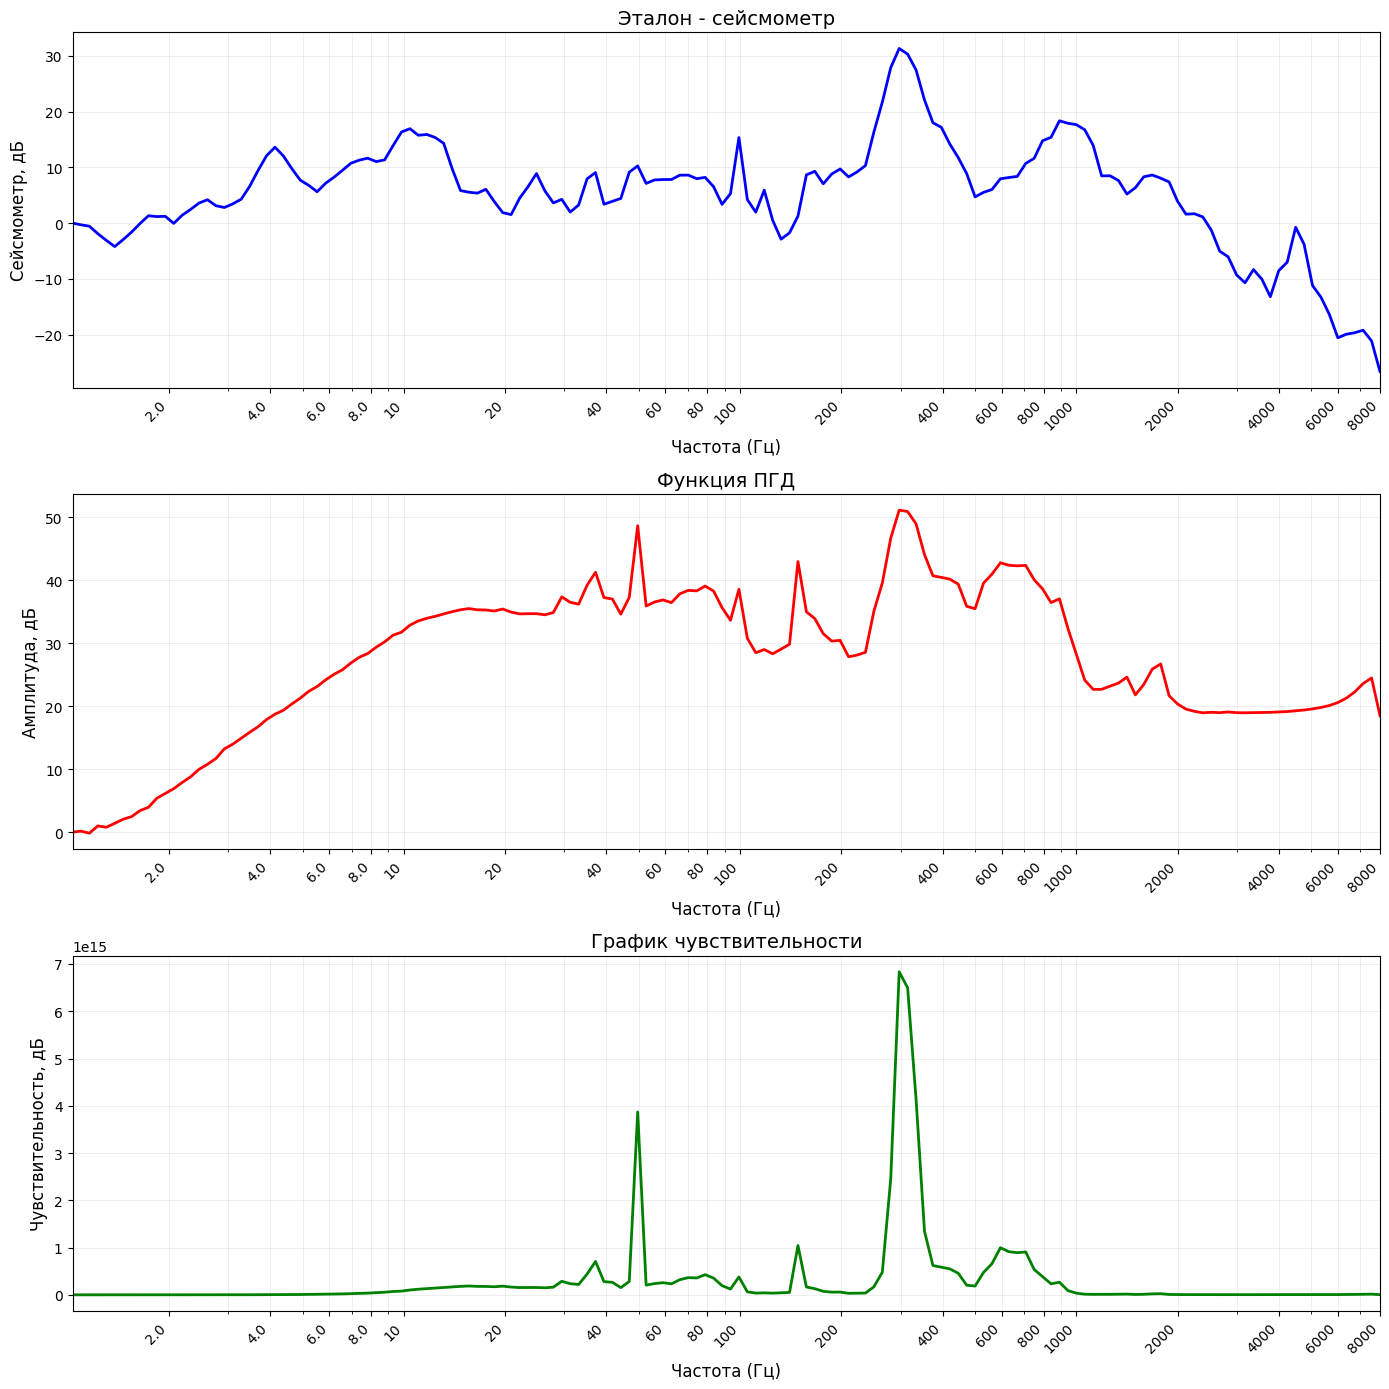

In [38]:
wav_file = '/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-1.wav'

fs, data = wavfile.read(wav_file)

if __name__ == "__main__":
    freqs, cal_db, sens = calibrate_from_ambient_noise(data, fs, segment_duration=60)


Типы наборов: [58 58]

Загружено:
  Частот: 147654656
  Диапазон: 0.00 - 18024.20 Гц
  Эквивалентная fs: 36048.4 Гц
FS: 16384 Гц, Длительность: 2.5 ч, Сегментов: 751
1/12 октавных полос: 155 (1.10 - 8000.0 Гц)


Обработка: 100%|██████████| 751/751 [00:05<00:00, 147.94it/s]


Валидных сегментов: 751/751


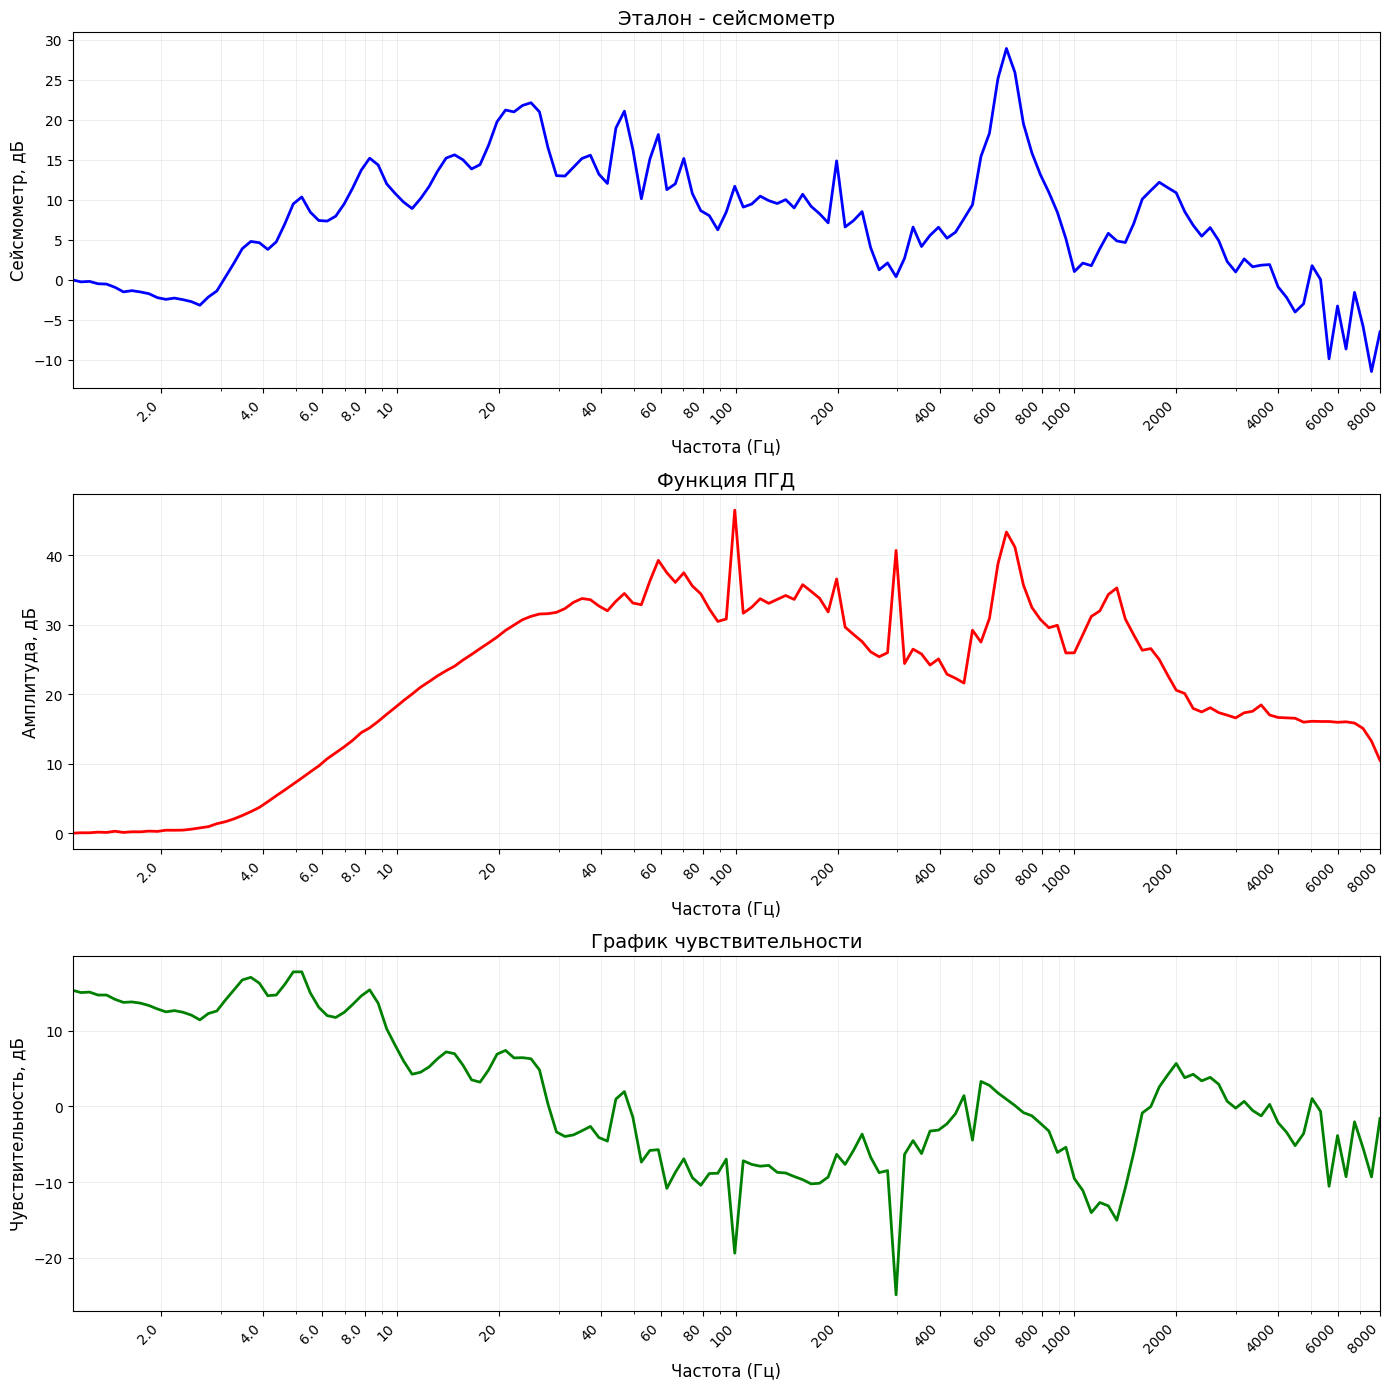

In [ ]:
# fs_uff, data_uff, freqs_uff = load_uff_as_wav_format('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-2.uff')

# if __name__ == "__main__":
#     freqs, cal_db, sens = calibrate_from_ambient_noise(data_uff, fs, segment_duration=12)

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_8989/2256839620.py:192: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-1.wav')


FS: 16384 Гц, Длительность: 0.9 ч, Сегментов: 51
1/12 октавных полос: 156 (1.03 - 8000.0 Гц)


Обработка: 100%|██████████| 51/51 [00:01<00:00, 33.35it/s]


Валидных сегментов: 51/51


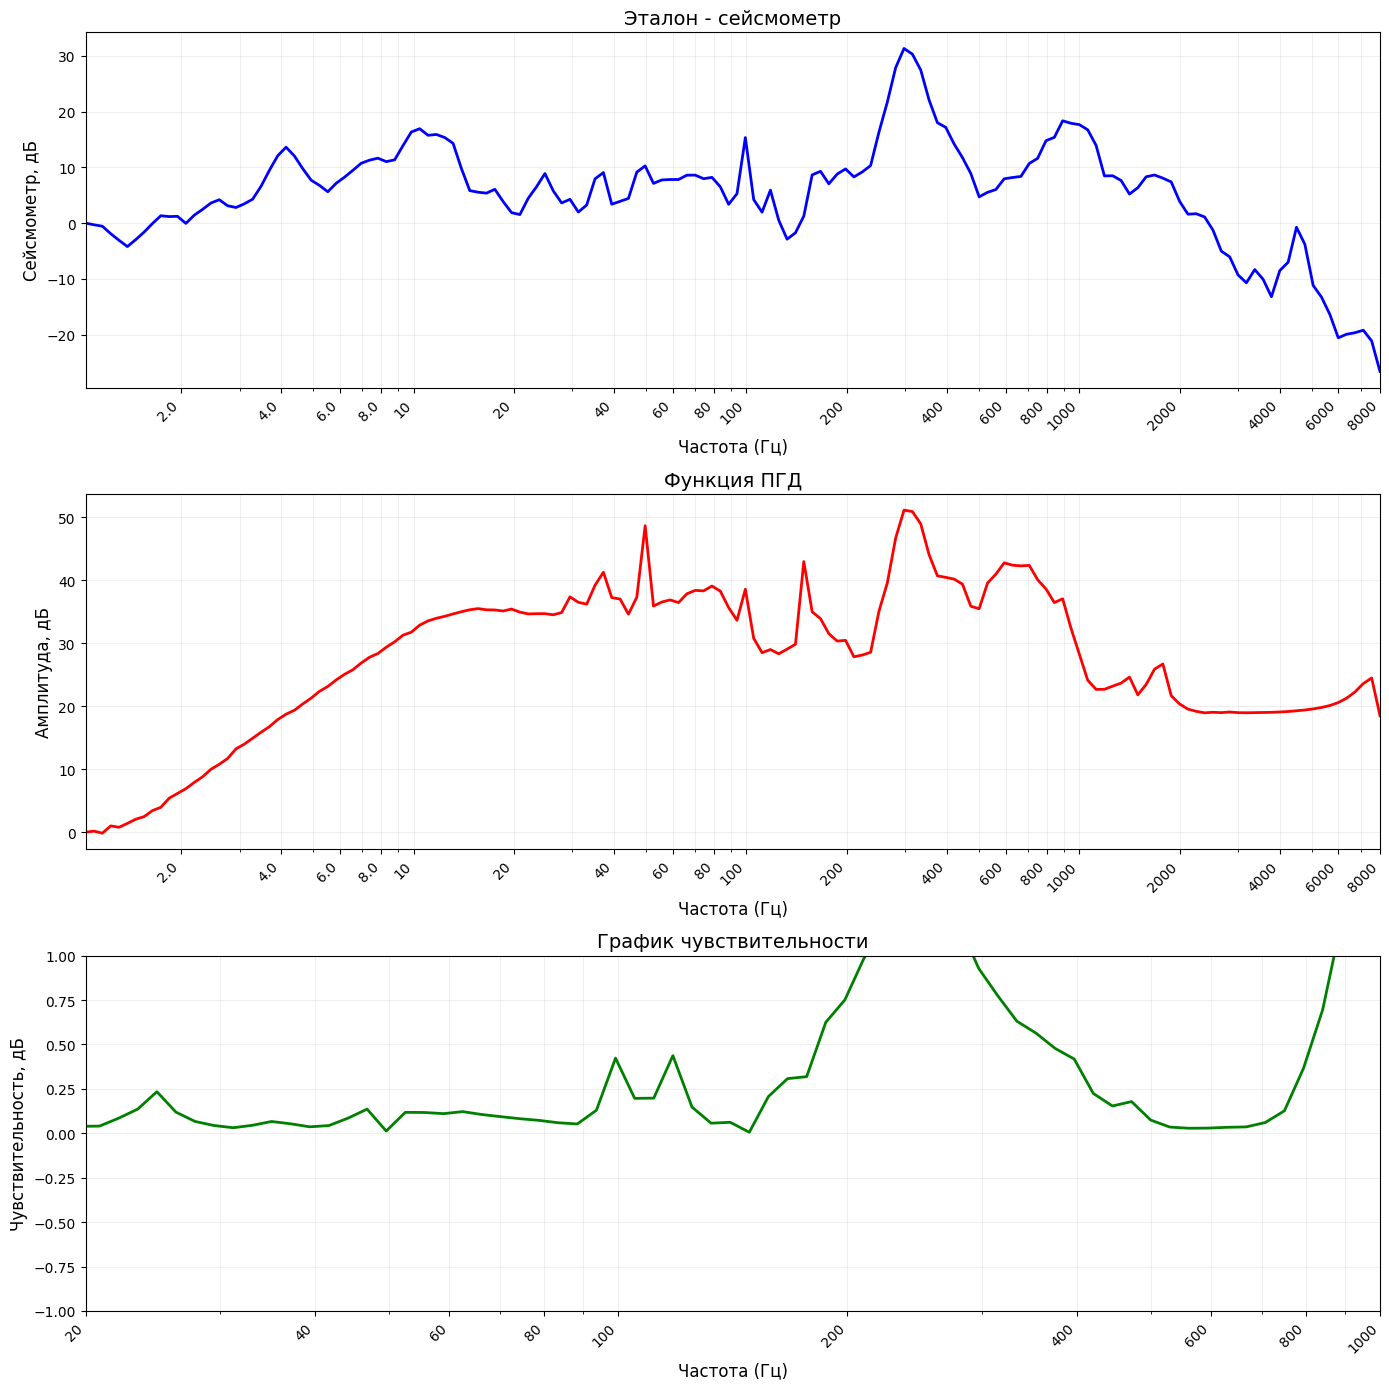

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter, LogLocator
import matplotlib.ticker as ticker

def plot_calibration_results(valid_freqs, micr_mc2, pgd_volt, sensitivity):
    """
    Функция для построения графиков калибровки
    
    Parameters:
    -----------
    valid_freqs : array
        Массив частот
    micr_mc2 : array
        Данные сейсмометра в дБ
    pgd_volt : array
        Данные ПГД в дБ
    sensitivity : array
        Данные чувствительности
    """
    
    # Функция для форматирования подписей частот
    def freq_formatter(x, pos):
        if x < 0.1:
            return f'{x:.3f}'
        elif x < 1:
            return f'{x:.2f}'
        elif x < 10:
            return f'{x:.1f}'
        else:
            return f'{x:.0f}'
    
    # Функция для создания логарифмических подписей
    def get_log_ticks(min_freq, max_freq):
        ticks = []
        bases = [1, 2, 4, 6, 8]
        
        start_order = int(np.floor(np.log10(min_freq)))
        end_order = int(np.ceil(np.log10(max_freq)))
        
        for order in range(start_order - 1, end_order + 1):
            for base in bases:
                tick = base * (10 ** order)
                if min_freq <= tick <= max_freq:
                    ticks.append(tick)
        
        if min_freq < 1:
            for base in [0.2, 0.4, 0.6, 0.8]:
                if min_freq <= base <= max_freq:
                    ticks.append(base)
        
        return sorted(set(ticks))
    
    # Создание фигуры с тремя подграфиками
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))
    
    # Получаем метки для осей X
    freq_ticks = get_log_ticks(valid_freqs[0], valid_freqs[-1])
    
    # График 1: Сейсмометр
    ax1.semilogx(valid_freqs, micr_mc2, 'b-', linewidth=2)
    ax1.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax1.set_xticks(freq_ticks)
    ax1.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax1.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax1.set_xlabel('Частота (Гц)', fontsize=12)
    ax1.set_ylabel('Сейсмометр, дБ', fontsize=12)
    ax1.set_title('Эталон - сейсмометр', fontsize=14)
    ax1.set_xlim([valid_freqs[0], valid_freqs[-1]])
    ax1.tick_params(axis='both', which='major', labelsize=10)
    
    # График 2: ПГД
    ax2.semilogx(valid_freqs, pgd_volt, 'r-', linewidth=2)
    ax2.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax2.set_xticks(freq_ticks)
    ax2.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax2.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax2.set_xlabel('Частота (Гц)', fontsize=12)
    ax2.set_ylabel('Амплитуда, дБ', fontsize=12)
    ax2.set_title('Функция ПГД', fontsize=14)
    ax2.set_xlim([valid_freqs[0], valid_freqs[-1]])
    ax2.tick_params(axis='both', which='major', labelsize=10)
    
    # График 3: Чувствительность
    ax3.semilogx(valid_freqs, sensitivity, 'g-', linewidth=2)
    ax3.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax3.set_xticks(freq_ticks)
    ax3.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax3.set_xlabel('Частота (Гц)', fontsize=12)
    ax3.set_ylabel('Чувствительность, дБ', fontsize=12)
    ax3.set_title('График чувствительности', fontsize=14)
    ax3.set_xlim([20, 1000])  # Ограничение по X от 20 Гц до 1000 Гц
    ax3.set_ylim([-1, 1])      # Ограничение по Y от -1 до 1 дБ
    ax3.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
    plt.show()


def calibrate_from_ambient_noise(data, fs, segment_duration=60, plot=True):
    
    micr = data[:, 0] - np.mean(data[:, 0])
    pgd = data[:, 1] - np.mean(data[:, 1])
    
    # 2. Параметры обработки
    seg_samples = int(segment_duration * fs)
    n_segments = len(micr) // seg_samples
    
    print(f"FS: {fs} Гц, Длительность: {len(micr)/fs/3600:.1f} ч, Сегментов: {n_segments}")
    
    # 3. Расчет 1/12 октавных частот
    micr_freq = 1000.0
    n_min = int(12 * np.log2(1 / micr_freq))
    n_max = int(12 * np.log2((fs/2) / micr_freq))
    f_centers = micr_freq * (2 ** (np.arange(n_min, n_max + 1) / 12))
    
    # 4. Подготовка масок для фильтрации
    nfft = seg_samples 
    freqs = np.fft.rfftfreq(nfft, 1/fs)
    
    filters = []
    valid_freqs = []
    for fc in f_centers:
        f_low = fc / 2**(1/24)
        f_high = fc * 2**(1/24)
        mask = (freqs >= f_low) & (freqs < f_high)
        if np.any(mask):
            filters.append(mask)
            valid_freqs.append(fc)
    
    n_bands = len(filters)
    print(f"1/12 октавных полос: {n_bands} ({valid_freqs[0]:.2f} - {valid_freqs[-1]:.1f} Гц)")
    
    # 5. Накопление спектров
    micr_power_sum = np.zeros(n_bands)
    pgd_power_sum = np.zeros(n_bands)
    valid_segments = 0
    
    for i in tqdm(range(n_segments), desc="Обработка"):
        start = i * seg_samples
        micr_seg = micr[start:start + seg_samples]
        pgd_seg = pgd[start:start + seg_samples]
        
        micr_fft = np.fft.rfft(micr_seg)
        pgd_fft = np.fft.rfft(pgd_seg)
        
        # Спектр мощности
        micr_power = np.abs(micr_fft)**2 / seg_samples
        pgd_power = np.abs(pgd_fft)**2 / seg_samples
        
        # Усреднение по октавным полосам
        for j, mask in enumerate(filters):
            if np.any(mask):
                micr_power_sum[j] += np.mean(micr_power[mask])
                pgd_power_sum[j] += np.mean(pgd_power[mask])
        
        valid_segments += 1
    
    print(f"Валидных сегментов: {valid_segments}/{n_segments}")
    
    # 6. Усреднение
    micr_power_avg = micr_power_sum / valid_segments
    pgd_power_avg = pgd_power_sum / valid_segments
    
    micr_mc2 = 10 * np.log10(micr_power_avg / micr_power_avg[0])
    pgd_volt = 10 * np.log10(pgd_power_avg / pgd_power_avg[0])
    sensitivity = (micr_power_avg / pgd_power_avg)
    
    # Построение графиков через отдельную функцию
    if plot:
        plot_calibration_results(valid_freqs, micr_mc2, pgd_volt, sensitivity)
    
    return np.array(valid_freqs), micr_mc2, sensitivity


# Пример использования
if __name__ == "__main__":
    # Загрузка данных из WAV файла
    fs, data = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-1.wav')
    freqs, cal_db, sens = calibrate_from_ambient_noise(data, fs, segment_duration=60)

NameError: name 'valid_freqs' is not defined

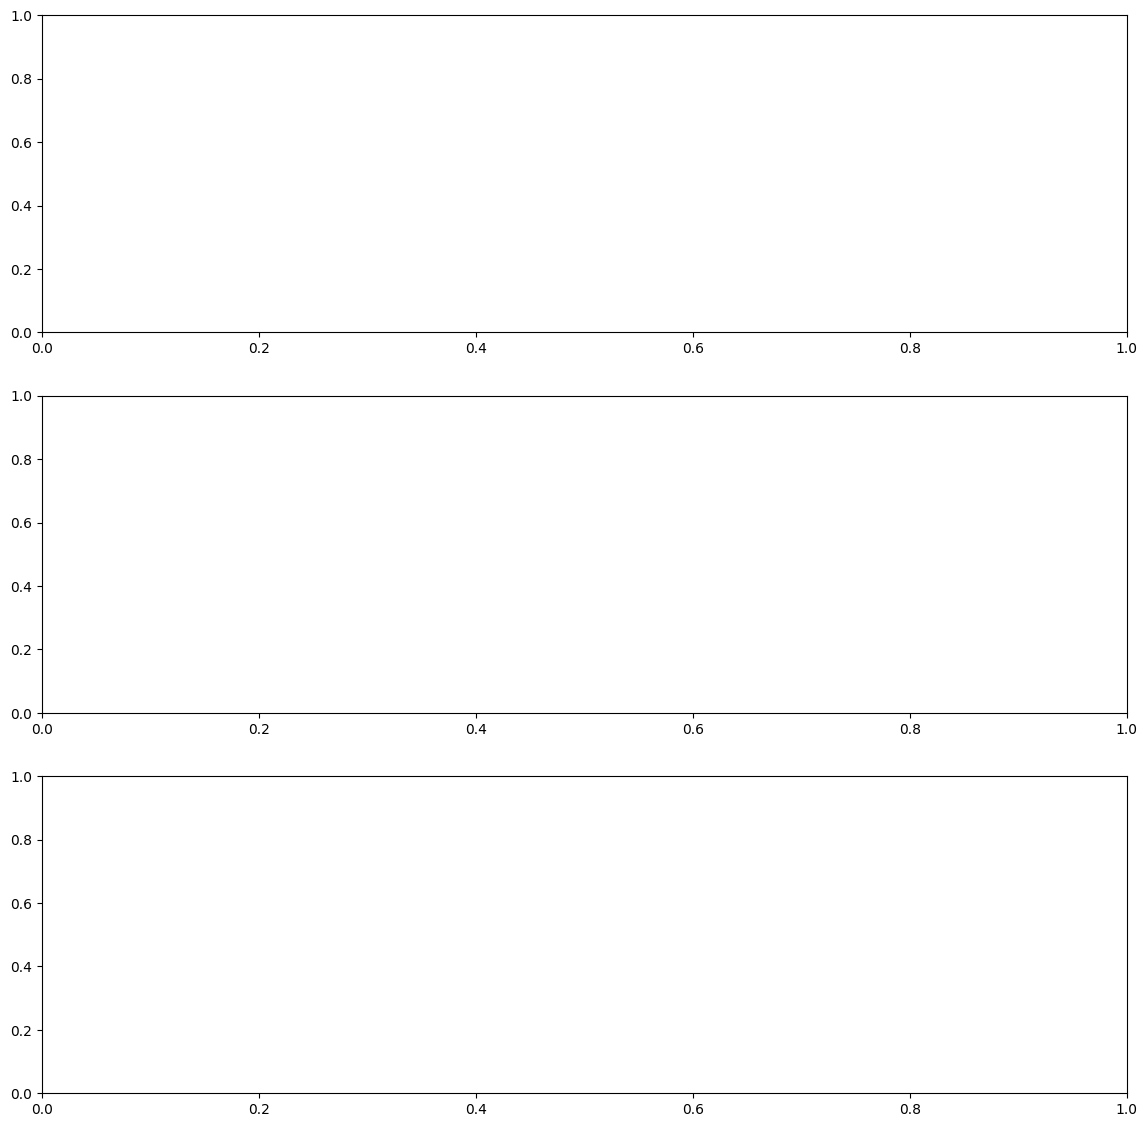

In [ ]:
def plot_calibration_results(valid_freqs, micr_mc2):
    """
    Функция для построения графиков калибровки
    
    Parameters:
    -----------
    valid_freqs : array
        Массив частот
    micr_mc2 : array
        Данные сейсмометра в дБ
    pgd_volt : array
        Данные ПГД в дБ
    sensitivity : array
        Данные чувствительности
    """
    
    # Функция для форматирования подписей частот
    def freq_formatter(x, pos):
        if x < 0.1:
            return f'{x:.3f}'
        elif x < 1:
            return f'{x:.2f}'
        elif x < 10:
            return f'{x:.1f}'
        else:
            return f'{x:.0f}'
    
    # Функция для создания логарифмических подписей
    def get_log_ticks(min_freq, max_freq):
        ticks = []
        bases = [1, 2, 4, 6, 8]
        
        start_order = int(np.floor(np.log10(min_freq)))
        end_order = int(np.ceil(np.log10(max_freq)))
        
        for order in range(start_order - 1, end_order + 1):
            for base in bases:
                tick = base * (10 ** order)
                if min_freq <= tick <= max_freq:
                    ticks.append(tick)
        
        if min_freq < 1:
            for base in [0.2, 0.4, 0.6, 0.8]:
                if min_freq <= base <= max_freq:
                    ticks.append(base)
        
        return sorted(set(ticks))
    
    # Создание фигуры с тремя подграфиками
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))
    
    # Получаем метки для осей X
    freq_ticks = get_log_ticks(valid_freqs[0], valid_freqs[-1])
    
    # График 1: Сейсмометр
    ax1.semilogx(valid_freqs, micr_mc2, 'b-', linewidth=2)
    ax1.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax1.set_xticks(freq_ticks)
    ax1.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax1.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax1.set_xlabel('Частота (Гц)', fontsize=12)
    ax1.set_ylabel('Сейсмометр, дБ', fontsize=12)
    ax1.set_title('Эталон - сейсмометр', fontsize=14)
    ax1.set_xlim([valid_freqs[0], valid_freqs[-1]])
    ax1.tick_params(axis='both', which='major', labelsize=10)
    
    # График 2: ПГД
    ax2.semilogx(valid_freqs, pgd_volt, 'r-', linewidth=2)
    ax2.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax2.set_xticks(freq_ticks)
    ax2.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax2.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax2.set_xlabel('Частота (Гц)', fontsize=12)
    ax2.set_ylabel('Амплитуда, дБ', fontsize=12)
    ax2.set_title('Функция ПГД', fontsize=14)
    ax2.set_xlim([valid_freqs[0], valid_freqs[-1]])
    ax2.tick_params(axis='both', which='major', labelsize=10)
    
    # График 3: Чувствительность
    ax3.semilogx(valid_freqs, sensitivity, 'g-', linewidth=2)
    ax3.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax3.set_xticks(freq_ticks)
    ax3.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax3.set_xlabel('Частота (Гц)', fontsize=12)
    ax3.set_ylabel('Чувствительность, дБ', fontsize=12)
    ax3.set_title('График чувствительности', fontsize=14)
    ax3.set_xlim([20, 1000])  # Ограничение по X от 20 Гц до 1000 Гц
    ax3.set_ylim([-1, 1])      # Ограничение по Y от -1 до 1 дБ
    ax3.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
    plt.show()
